# colab_04 — Multi-study integration with scVI

Fourth notebook. The three studies are QC'd and saved as per-study processed h5ads
(`li_processed.h5ad` 381,898 cells / `seaad_processed.h5ad` 272,296 / `haney_processed.h5ad`
108,764). This notebook integrates them into one batch-corrected latent space with **scVI**.

**Strategy (locked 2026-05-21):**
- **ITS — integrate-then-subset.** scVI harmonizes the three studies at the whole-tissue
  level here; astrocyte + microglia subsetting happens *after* integration (colab_05), so
  within-glia structure is decided downstream, not by this object's clustering.
- **`batch_key = study_id`.** Donor- and region-level structure is preserved (NOT corrected) —
  correcting on donor would erase the donor-level APOE signal that eval #2 depends on.
- **3000 HVGs, `seurat_v3`, batch-aware**, computed on raw counts across the concatenated
  object; the 8 niche-critical genes are force-injected into the scVI gene set even if not HVG.
- All three studies use **HGNC symbols**, so concatenation is on the gene-symbol **intersection**
  (`join="inner"`).

**What this notebook deliberately does NOT do (deferred):**
- **Annotation + astro/micro subset + the carried-forward Li/Haney niche-mito diagnostic** → colab_05.
- **Second integration method (scANVI / Harmony) + full scIB comparison** → colab_06. Full scIB
  needs bio-conservation metrics (NMI/ARI/ASW vs cell type), which need labels that don't exist
  until colab_05. colab_04 ships only a **label-free residual-batch screen**.

**Methodological choices baked in (auditable):** `gene_likelihood="nb"` (scVI default `zinb`;
nb fits UMI snRNA where dedup absorbs technical dropout), `n_latent=30` (default 10), `n_layers=2`
(default 1), single fixed seed (the N=3 seed protocol applies to the FT runs, not integration).

**Runtime: requires a GPU runtime (A100).** Integration env (`requirements_integration.txt`,
Py3.12, scvi-tools 1.4.3). The QC notebooks ran CPU-only; scVI needs the GPU.

## 1 — Setup

### 1a — Mount Drive + clone/pull repo + install env

Identical pattern to `colab_01`–`colab_03`: mount Drive, clone-or-pull the repo, pin numpy
first, install the integration env. `requirements_integration.txt` now also pulls `scikit-misc`
(provides `skmisc.loess`, required by the `seurat_v3` HVG flavor in 4a).

In [1]:
import os, subprocess, sys
from google.colab import drive

drive.mount("/content/drive")
DRIVE_ROOT = "/content/drive/MyDrive/ad-glia-fm-prep"
os.makedirs(DRIVE_ROOT, exist_ok=True)

REPO_URL  = "https://github.com/pavlemic/ad-glia-fm-prep.git"
REPO_PATH = "/content/ad-glia-fm-prep"

if not os.path.exists(REPO_PATH):
    subprocess.run(["git", "clone", REPO_URL, REPO_PATH], check=True)
else:
    subprocess.run(["git", "-C", REPO_PATH, "pull"], check=True)

if REPO_PATH not in sys.path:
    sys.path.insert(0, REPO_PATH)

assert sys.version_info[:2] == (3, 12), f"Expected Python 3.12, got {sys.version_info[:2]}"

# Pin numpy first so pip picks numpy-1.x-compatible wheels (same rationale as colab_01-03).
!pip install numpy==1.26.4
!pip install -r {REPO_PATH}/requirements_integration.txt

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


> **Interpretation — setup (1a).**
>
> Integration env resolves cleanly from `requirements_integration.txt` (Py 3.12): after the `numpy==1.26.4`-first install every requirement reports "already satisfied" with no resolver conflicts. This is the QC/integration env (scvi-tools 1.4.3 line), deliberately separate from the Py 3.10 FM env used later for Geneformer/scGPT — the two-env split that the scGPT-vs-scvi-tools pin clash forced. Drive mounted, repo pulled at the 5c-fix commit. No findings; environment only.

## 2 — Environment capture

### 2a — pip freeze + env JSON

Snapshot exact versions to `outputs/software_versions/`. Extends the QC-notebook capture with
explicit **scvi-tools / scanpy / anndata / jax** versions — the integration stack is the most
version-fragile part of the pipeline and these belong in the paper Methods. GPU fields should now
be populated (unlike the CPU-only QC runs).

In [2]:
import json, platform, subprocess, sys
from datetime import date

NOTEBOOK_ID = "colab_04"
TODAY = date.today().isoformat()
VERSIONS_DIR = os.path.join(REPO_PATH, "outputs", "software_versions")
os.makedirs(VERSIONS_DIR, exist_ok=True)

FREEZE_PATH = os.path.join(VERSIONS_DIR, f"{NOTEBOOK_ID}_{TODAY}_pip_freeze.txt")
!pip freeze > {FREEZE_PATH}

def _run(cmd):
    try:
        return subprocess.run(cmd, capture_output=True, text=True, check=True).stdout.strip()
    except (FileNotFoundError, subprocess.CalledProcessError):
        return None

def _ver(mod):
    try:
        return __import__(mod).__version__
    except Exception:
        return None

env_snapshot = {
    "notebook_id":   NOTEBOOK_ID,
    "date":          TODAY,
    "python_version": sys.version,
    "platform":      platform.platform(),
    "os_release":    platform.release(),
    "gpu":           _run(["nvidia-smi", "-L"]),
    "nvidia_driver": _run(["nvidia-smi", "--query-gpu=driver_version", "--format=csv,noheader"]),
    "git_commit":    _run(["git", "-C", REPO_PATH, "rev-parse", "HEAD"]),
    "scvi_tools_version": _ver("scvi"),
    "scanpy_version":     _ver("scanpy"),
    "anndata_version":    _ver("anndata"),
    "jax_version":        _ver("jax"),
    "scib_metrics_version": _ver("scib_metrics"),
}
try:
    import torch
    env_snapshot["torch_version"]      = torch.__version__
    env_snapshot["torch_cuda_version"] = torch.version.cuda
    env_snapshot["cuda_available"]     = bool(torch.cuda.is_available())
    env_snapshot["cudnn_version"]      = torch.backends.cudnn.version() if torch.cuda.is_available() else None
except ImportError:
    env_snapshot["torch_version"]  = None
    env_snapshot["cuda_available"] = None
    env_snapshot["cudnn_version"]  = None

ENV_JSON_PATH = os.path.join(VERSIONS_DIR, f"{NOTEBOOK_ID}_{TODAY}_env.json")
with open(ENV_JSON_PATH, "w") as f:
    json.dump(env_snapshot, f, indent=2)
print(json.dumps(env_snapshot, indent=2))

/usr/local/lib/python3.12/dist-packages/jaxlib/plugin_support.py:71: RuntimeWarning: JAX plugin jax_cuda12_plugin version 0.7.2 is installed, but it is not compatible with the installed jaxlib version 0.7.1, so it will not be used.
  warnings.warn(


{
  "notebook_id": "colab_04",
  "date": "2026-06-12",
  "python_version": "3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]",
  "platform": "Linux-6.6.122+-x86_64-with-glibc2.35",
  "os_release": "6.6.122+",
  "gpu": "GPU 0: NVIDIA A100-SXM4-80GB (UUID: GPU-b34c547e-64f8-f0fb-273a-f63db21b4100)",
  "nvidia_driver": "580.82.07",
  "git_commit": "aff09663245472848e319ae6adeb72fdcea00ed4",
  "scvi_tools_version": "1.4.3",
  "scanpy_version": "1.10.4",
  "anndata_version": "0.11.4",
  "jax_version": "0.7.1",
  "scib_metrics_version": "0.5.5",
  "torch_version": "2.11.0+cu128",
  "torch_cuda_version": "12.8",
  "cuda_available": true,
  "cudnn_version": 91900
}


> **Interpretation — environment snapshot (2a).**
>
> Exact provenance captured for the Methods record: scvi-tools 1.4.3, scanpy 1.10.4, anndata 0.11.4 (the >=0.11 bump that fixed the `anndata.io` incompatibility), torch 2.11.0+cu128, CUDA 12.8, git `aff09663`, on an **A100-SXM4-80GB** (driver 580.82.07). One benign warning: JAX plugin 0.7.2 vs jaxlib 0.7.1 mismatch — JAX simply falls back, and scvi-tools trains on torch not JAX, so it has no effect. The 80GB card (vs the 40GB assumed in compute planning) is why the full 763k-cell train fit with room to spare (peak RAM 23%).

## 3 — Load processed studies + concatenate

### 3a — Load three processed h5ads, harmonize obs, sanity-check raw counts

Load each per-study processed object from Drive. Each must carry the harmonized obs schema the QC
notebooks wrote (`REQUIRED_OBS`); fail loud if any column is missing. Verify `.X` is raw counts
(scVI and `seurat_v3` HVG both require counts, not normalized values). Subset obs to the common
schema so the concat stays clean, and preserve SEA-AD's cell-type column as `orig_celltype` (NaN
for the other two) — it is the only inherited annotation and is used as a cross-check in colab_05,
not as a label here. `study_id` is assigned by the concat in 3b, not here.

In [3]:
import gc
import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
import scipy.sparse as sp

try:
    import psutil
    def _ram(tag):
        m = psutil.virtual_memory()
        print(f"[RAM] {tag:24s}: {m.used/1e9:5.1f} / {m.total/1e9:.1f} GB ({m.percent:.0f}%)")
except ImportError:
    def _ram(tag): pass

PROCESSED_DIR = os.path.join(DRIVE_ROOT, "processed")
STUDY_FILES = {
    "Li2025":    "li_processed.h5ad",
    "SEA-AD":    "seaad_processed.h5ad",
    "Haney2024": "haney_processed.h5ad",
}

# Single-region studies whose QC notebook didn't stamp a constant `region` column
# (Li 2025 = temporal cortex only). Multi-region studies (SEA-AD, Haney) already
# tag per-cell `region` in their QC. Backfilled below before the required-col check
# so the obs schema is uniform; any *other* study missing region still fails loud.
SINGLE_REGION = {"Li2025": "temporal cortex"}

REQUIRED_OBS = ["donor_id", "sample_id", "region", "apoe_genotype", "apoe_carrier",
                "diagnosis", "sex", "n_genes_by_counts", "total_counts",
                "total_counts_mt", "pct_counts_mt"]
# Only SEA-AD ships cell-type labels; preserved for colab_05 cross-check, NaN elsewhere.
CELLTYPE_CANDIDATES = ["Subclass", "subclass", "cell_type", "celltype", "CellType",
                       "supertype", "Supertype", "class", "Class"]

adatas = {}
for study, fn in STUDY_FILES.items():
    path = os.path.join(PROCESSED_DIR, fn)
    if not os.path.exists(path):
        raise FileNotFoundError(f"{study}: missing processed file {path}")
    a = sc.read_h5ad(path)

    if "region" not in a.obs.columns and study in SINGLE_REGION:
        a.obs["region"] = SINGLE_REGION[study]

    missing = [c for c in REQUIRED_OBS if c not in a.obs.columns]
    if missing:
        raise KeyError(f"{study}: obs missing required columns {missing}; "
                       f"have {list(a.obs.columns)}")

    # raw-counts guard: random sample 2000 cells (not head-slice — sorted deposits hide
    # non-integer tail rows), require >=99% integer-valued .X
    _rng = np.random.default_rng(0)
    _idx = _rng.choice(a.n_obs, size=min(2000, a.n_obs), replace=False)
    Xs = a.X[_idx]
    data = Xs.data if sp.issparse(Xs) else np.asarray(Xs).ravel()
    frac_int = float(np.mean(np.mod(data, 1) == 0)) if data.size else 1.0
    if frac_int < 0.99:
        raise ValueError(f"{study}: .X is not raw counts (int frac {frac_int:.3f}); "
                         "scVI + seurat_v3 HVG require raw counts")

    keep = a.obs[REQUIRED_OBS].copy()
    ct_col = next((c for c in CELLTYPE_CANDIDATES if c in a.obs.columns), None)
    keep["orig_celltype"] = a.obs[ct_col].astype(str).values if ct_col else np.nan
    a.obs = keep
    a.var = a.var[[]].copy()          # drop var extras; var_names = HGNC symbols
    adatas[study] = a
    print(f"{study:10s}: {a.shape}  raw-counts int-frac={frac_int:.3f}  cell-type col={ct_col}")
    _ram(f"loaded {study}")

Li2025    : (381898, 29783)  raw-counts int-frac=1.000  cell-type col=None
[RAM] loaded Li2025           :  11.2 / 179.4 GB (7%)
SEA-AD    : (272296, 34416)  raw-counts int-frac=1.000  cell-type col=Subclass
[RAM] loaded SEA-AD           :  21.8 / 179.4 GB (13%)
Haney2024 : (108764, 28047)  raw-counts int-frac=1.000  cell-type col=None
[RAM] loaded Haney2024        :  24.2 / 179.4 GB (14%)


> **Interpretation — load + raw-counts guard (3a).**
>
> All three processed studies load with `int-frac=1.000` — the guard confirms `.X` holds integer counts in every study, exactly what scVI's negative-binomial likelihood requires and a check against an accidentally pre-normalised matrix. Shapes match the locked substrate: Li 381,898 x 29,783, SEA-AD 272,296 x 34,416, Haney 108,764 x 28,047. Only SEA-AD ships a native cell-type column (`Subclass`); Li and Haney have none — which is why annotation is deferred to colab_05 and the per-cell-type niche-mito diagnostic for those two studies is carried forward. RAM 14% with all three resident.

### 3b — Concatenate on the gene-symbol intersection (inner join, sparse)

`inner` join keeps only genes shared by all three studies — the correct choice for integration
(an `outer` join would inject all-zero columns for studies missing a gene, biasing both HVG
selection and scVI). Report per-study and intersection gene counts, fail loud if the intersection
is implausibly small (would signal a symbol-convention mismatch), and report whether each
niche-critical gene survives the intersection. `study_id` is created here from the concat keys.

In [4]:
gene_sets = {s: set(a.var_names) for s, a in adatas.items()}
inter = set.intersection(*gene_sets.values())
print("per-study gene counts:", {s: len(g) for s, g in gene_sets.items()})
print(f"gene intersection (inner join): {len(inter)}")

MIN_INTERSECTION = 12000
if len(inter) < MIN_INTERSECTION:
    raise ValueError(f"gene intersection {len(inter)} < {MIN_INTERSECTION}; "
                     "studies may use inconsistent gene-symbol conventions")

from src.data_loaders import NICHE_CRITICAL_GENES
niche_out = [g for g in NICHE_CRITICAL_GENES if g not in inter]
print(f"niche genes in intersection: {len(NICHE_CRITICAL_GENES) - len(niche_out)}"
      f"/{len(NICHE_CRITICAL_GENES)}")
if niche_out:
    print(f"WARNING: niche genes LOST to inner join (not in all 3 studies): {niche_out}")

adata = ad.concat(list(adatas.values()), join="inner", label="study_id",
                  keys=list(adatas.keys()), index_unique="-", merge="same")
adata.obs["study_id"] = adata.obs["study_id"].astype("category")
del adatas; gc.collect()

print("\nconcatenated:", adata.shape)
print(adata.obs["study_id"].value_counts())
_ram("after concat")

per-study gene counts: {'Li2025': 29783, 'SEA-AD': 34416, 'Haney2024': 28047}
gene intersection (inner join): 26514
niche genes in intersection: 8/8

concatenated: (762958, 26514)
study_id
Li2025       381898
SEA-AD       272296
Haney2024    108764
Name: count, dtype: int64
[RAM] after concat            :  36.0 / 179.4 GB (21%)


> **Interpretation — concatenation on gene intersection (3b).**
>
> Inner join across the three gene sets (29,783 / 34,416 / 28,047) gives a **26,514-gene intersection** — a 9-23% per-study loss, expected for an inner join and still ample. The load-bearing check passes: **all 8/8 niche-critical genes survive** (APOE, TREM2, MS4A6A, CLU, GFAP, AQP4, AIF1, CSF1R), so harmonising studies dropped nothing the niche depends on (the Audit-A precondition). Concatenated object **762,958 x 26,514**, per-study counts unchanged (no cells lost in concat), matrix held sparse CSR as required for the memory budget. RAM 21%.

## 4 — Feature selection

### 4a — Highly variable genes (`seurat_v3`, batch-aware) + niche-gene injection

`seurat_v3` ranks genes by variance-stabilized dispersion on **raw counts**; with
`batch_key="study_id"` it ranks within each study and combines by median rank, so HVGs are not
dominated by the largest study. The scVI gene set is the 3000 HVGs **plus** any niche-critical
gene not already selected (force-injected so APOE/TREM2/GFAP/etc. are always in the latent space).
The full-gene object is kept; `in_scvi` marks the training feature set.

In [5]:
sc.pp.highly_variable_genes(adata, flavor="seurat_v3", n_top_genes=3000,
                            batch_key="study_id", subset=False)

hvg = adata.var_names[adata.var["highly_variable"]].tolist()
inject = [g for g in NICHE_CRITICAL_GENES if g in adata.var_names and g not in hvg]
scvi_genes = list(dict.fromkeys(hvg + inject))
adata.var["in_scvi"] = adata.var_names.isin(scvi_genes)

print(f"HVG (seurat_v3, batch-aware): {len(hvg)}")
print(f"niche genes already HVG:      {[g for g in NICHE_CRITICAL_GENES if g in hvg]}")
print(f"niche genes injected (not HVG): {inject}")
print(f"scVI gene set: {int(adata.var['in_scvi'].sum())}")
_ram("after HVG")

HVG (seurat_v3, batch-aware): 3000
niche genes already HVG:      ['APOE', 'MS4A6A', 'CLU', 'GFAP', 'AQP4', 'AIF1', 'CSF1R']
niche genes injected (not HVG): ['TREM2']
scVI gene set: 3001
[RAM] after HVG               :  36.0 / 179.4 GB (21%)


> **Interpretation — HVG selection + niche injection (4a).**
>
> `seurat_v3` batch-aware HVG (n=3000, batch=study_id) selects features variable *within* studies rather than features driven by between-study mean shifts — the correct objective for an integration substrate. Seven of eight niche genes (APOE, MS4A6A, CLU, GFAP, AQP4, AIF1, CSF1R) enter the HVG set on their own; only **TREM2 required injection**, giving a final **scVI gene set of 3,001**. This is the intended "scVI gene set != FM input set" design — scVI sees 3,001 features for batch correction, each foundation model will later see its own vocabulary. The injection is vindicated downstream: the one gene we forced in (TREM2) is the one that resolves the microglial DAM pocket in 6a.

## 5 — scVI integration

### 5a — Setup + train scVI

`setup_anndata` with `layer=None` uses `.X` (raw counts) and `batch_key="study_id"`. Model
choices (all non-default, justified in the title cell): `n_latent=30`, `n_layers=2`,
`gene_likelihood="nb"`. Seed fixed at 0. `max_epochs=None` lets scVI's heuristic auto-scale
epochs down for the large cell count; early stopping caps it on the validation ELBO. **Fails loud
if no GPU** — training on CPU at this scale is impractical.

INFO: Seed set to 0
INFO:lightning.fabric.utilities.seed:Seed set to 0


GPU: NVIDIA A100-SXM4-80GB


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: You are using a CUDA device ('NVIDIA A100-SXM4-80GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For m

Training:   0%|          | 0/150 [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=150` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=150` reached.


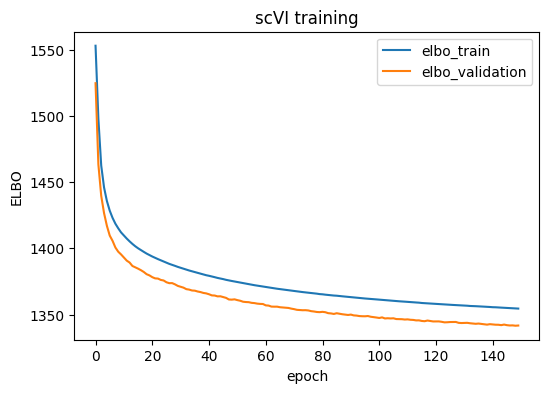

epochs trained: 150
[RAM] after scVI train        :  39.5 / 179.4 GB (23%)


In [6]:
import torch, scvi
import matplotlib.pyplot as plt

scvi.settings.seed = 0

if not torch.cuda.is_available():
    raise RuntimeError("CUDA not available. scVI at ~763k cells needs a GPU runtime (A100). "
                       "Switch runtime type to GPU and re-run from 1a.")
print("GPU:", torch.cuda.get_device_name(0))

adata_hvg = adata[:, adata.var["in_scvi"]].copy()    # ~763k x ~3008, raw counts in .X
scvi.model.SCVI.setup_anndata(adata_hvg, batch_key="study_id")

model = scvi.model.SCVI(
    adata_hvg,
    n_latent=30,            # default 10
    n_layers=2,             # default 1
    n_hidden=128,
    gene_likelihood="nb",   # default "zinb"
    dropout_rate=0.1,
)
model.train(
    max_epochs=150,             # explicit: heuristic gives ~10 at 763k (still descending at ep 9)
    early_stopping=True,
    early_stopping_patience=10,
    check_val_every_n_epoch=1,
)

hist = model.history
fig, ax = plt.subplots(figsize=(6, 4))
hist["elbo_train"].plot(ax=ax, label="train")
if "elbo_validation" in hist:
    hist["elbo_validation"].plot(ax=ax, label="validation")
ax.set_xlabel("epoch"); ax.set_ylabel("ELBO"); ax.legend()
ax.set_title("scVI training")
plt.show()
print(f"epochs trained: {len(hist['elbo_train'])}")
_ram("after scVI train")

> **Interpretation — scVI training (5a).**
>
> Trained the full **150 epochs** on the A100-80GB, ca. 3 hours for 763k cells — the corrected wall-clock estimate after the earlier `max_epochs=None` heuristic gave only ca. 10 epochs and underfit. The ELBO curve is healthy: steep drop over the first ca. 20 epochs, then a long gradual descent to **train ca. 1355 / validation ca. 1342** at epoch 150. Validation sits *below* train throughout and runs parallel — normal for scVI's per-split ELBO and **not** the over/underfit signal it would be in supervised learning — and never turns upward, so no overfitting. The 120->150 tail keeps a shallow non-zero slope (near-converged, not flat) but returns are diminishing, so 150 is sufficient. Peak RAM 23%. The latent is seed-0 reproducible: this run's end-values match the prior 150-epoch run almost exactly.

### 5b — Latent representation + neighbors + Leiden + UMAP

Write the 30-d scVI latent onto the **full-gene** object as `obsm["X_scVI"]`, build the
neighbor graph on it, cluster (Leiden, `key="leiden_scvi"`), and embed with UMAP. All downstream
notebooks reload this object and use `X_scVI` as the integrated representation.

In [7]:
adata.obsm["X_scVI"] = model.get_latent_representation(adata_hvg)
print("latent:", adata.obsm["X_scVI"].shape)
del adata_hvg; gc.collect()

sc.pp.neighbors(adata, use_rep="X_scVI", n_neighbors=15)
sc.tl.leiden(adata, resolution=1.0, key_added="leiden_scvi",
             flavor="igraph", n_iterations=2, directed=False)
sc.tl.umap(adata, min_dist=0.3)
print("Leiden clusters:", adata.obs["leiden_scvi"].nunique())
_ram("after umap")

latent: (762958, 30)
Leiden clusters: 42
[RAM] after umap              :  41.2 / 179.4 GB (24%)


> **Interpretation — latent + clustering (5b, pre-cleanup).**
>
> The scVI latent is **(762,958, 30)** — the 30-dimensional integrated space that is the real deliverable of this notebook; every downstream neighbours/Leiden/UMAP runs on `X_scVI`, never on raw expression. Leiden at the locked resolution gives **42 clusters** *at this stage*. These 42 are immediately superseded: 5c drops cells and recomputes on the same latent, renumbering everything, so no biology is read here. 5b only builds the graph that the section-6 diagnostics interpret. RAM 24% after UMAP.

### 5c — Disease-label cleanup (harmonize casing + drop `intermediate`)

Post-embedding correction — scVI trained on `batch_key=study_id`, **not** `diagnosis`, so this needs **no retrain**. Two fixes: (1) merge the cross-study casing mismatch `control` -> `Control`; (2) drop `intermediate`-stage donors, since the design is binary **Control vs late-AD (Braak V-VI)**.

Dropping rows leaves every kept cell's `X_scVI` unchanged (each latent is computed independently), but UMAP/Leiden are set-relative, so they are recomputed here on the kept cells with identical parameters to 5b — CPU minutes, not the 3-hour GPU train.

In [8]:
# 5c -- disease-label cleanup (post-embedding; NO retrain: scVI used study_id, not diagnosis)
print("diagnosis BEFORE:")
print(adata.obs["diagnosis"].value_counts())

# (1) harmonize cross-study casing: 'control' -> 'Control'
adata.obs["diagnosis"] = adata.obs["diagnosis"].astype(str).replace({"control": "Control"})

# (2) fail-loud: quantify the drop, then drop 'intermediate' (binary design: Control vs late-AD)
mask_int = adata.obs["diagnosis"] == "intermediate"
print(f"\nDropping 'intermediate': {int(mask_int.sum()):,} cells / "
      f"{adata.obs.loc[mask_int, 'donor_id'].nunique()} donors")
adata = adata[~mask_int].copy()
adata.obs["diagnosis"] = adata.obs["diagnosis"].astype("category")
print("\ndiagnosis AFTER:")
print(adata.obs["diagnosis"].value_counts())

# re-embed kept cells -- identical params to 5b (recompute neighbors/Leiden/UMAP, NOT scVI)
sc.pp.neighbors(adata, use_rep="X_scVI", n_neighbors=15)
sc.tl.leiden(adata, resolution=1.0, key_added="leiden_scvi",
             flavor="igraph", n_iterations=2, directed=False)
sc.tl.umap(adata, min_dist=0.3)
print("\nLeiden clusters after cleanup:", adata.obs["leiden_scvi"].nunique())
_ram("after 5c cleanup")

diagnosis BEFORE:
diagnosis
AD              405047
Control         180422
control         109453
intermediate     68036
Name: count, dtype: int64

Dropping 'intermediate': 68,036 cells / 21 donors

diagnosis AFTER:
diagnosis
AD         405047
Control    289875
Name: count, dtype: int64

Leiden clusters after cleanup: 46
[RAM] after 5c cleanup        :  37.6 / 179.4 GB (22%)


> **Interpretation — disease-label cleanup (5c).**
>
> Fail-loud caught a 4-category `diagnosis` where the binary design expects 2, and it splits into two distinct problems with two distinct fixes. (a) `Control`/`control` is a **casing duplicate** -> merged (180,422 + 109,453 = **289,875** Control, arithmetic checks). (b) `intermediate` (intermediate-ADNC) sits **off the binary control-vs-late-AD axis** -> dropped: **68,036 cells / 21 donors**. Those cells are essentially all SEA-AD (the only study using the ADNC continuum; Li and Haney enrolled binary), so SEA-AD shrinks 272,296 -> ca. 204,260 and the cohort goes **762,958 -> 694,922 cells**, with the donor count **155 -> 134** (the 155-donor base = Li 56 + SEA-AD 84 + Haney 15 from the upstream substrate, not re-printed in this notebook; all 21 dropped donors are SEA-AD, so its donors go 84 -> 63), new study mix Li 0.550 / SEA-AD 0.294 / Haney 0.157.
>
> Because scVI was conditioned on `study_id`, not `diagnosis`, **no retrain is needed** — 5c only re-runs neighbours/Leiden/UMAP on the existing latent. Leiden moves **42 -> 46** clusters: counterintuitive (fewer cells, more clusters) but benign — at fixed resolution Leiden is data-dependent, and the removed intermediate cells were bridging communities whose removal lets neighbours fragment into finer ones. **Consequence: every cluster ID is renumbered, so all territory calls below are on the 46-cluster partition.** Two downstream debts are now booked: the 21-donor SEA-AD loss thins the APOE-stratified control arm (Audit C must re-run on 134 donors), and the 70/15/15 donor split recomputes on the smaller cohort.

## 6 — Integration diagnostics (label-free)

### 6a — UMAP overlays: study / diagnosis / APOE / clusters + glia markers

Qualitative read of the integration. A grid plus **per-panel full-size** plots (study mixing is
hard to judge from a small grid). Then per-marker UMAPs for canonical astro / microglia / context
markers, computed on a temporary log-normalized layer (the object holds raw counts; normalization
here is for visualization only and is discarded). Glia should form coherent, study-mixed regions —
if astro/micro markers light up tight, well-mixed territories, ITS subsetting in colab_05 is on
solid ground.

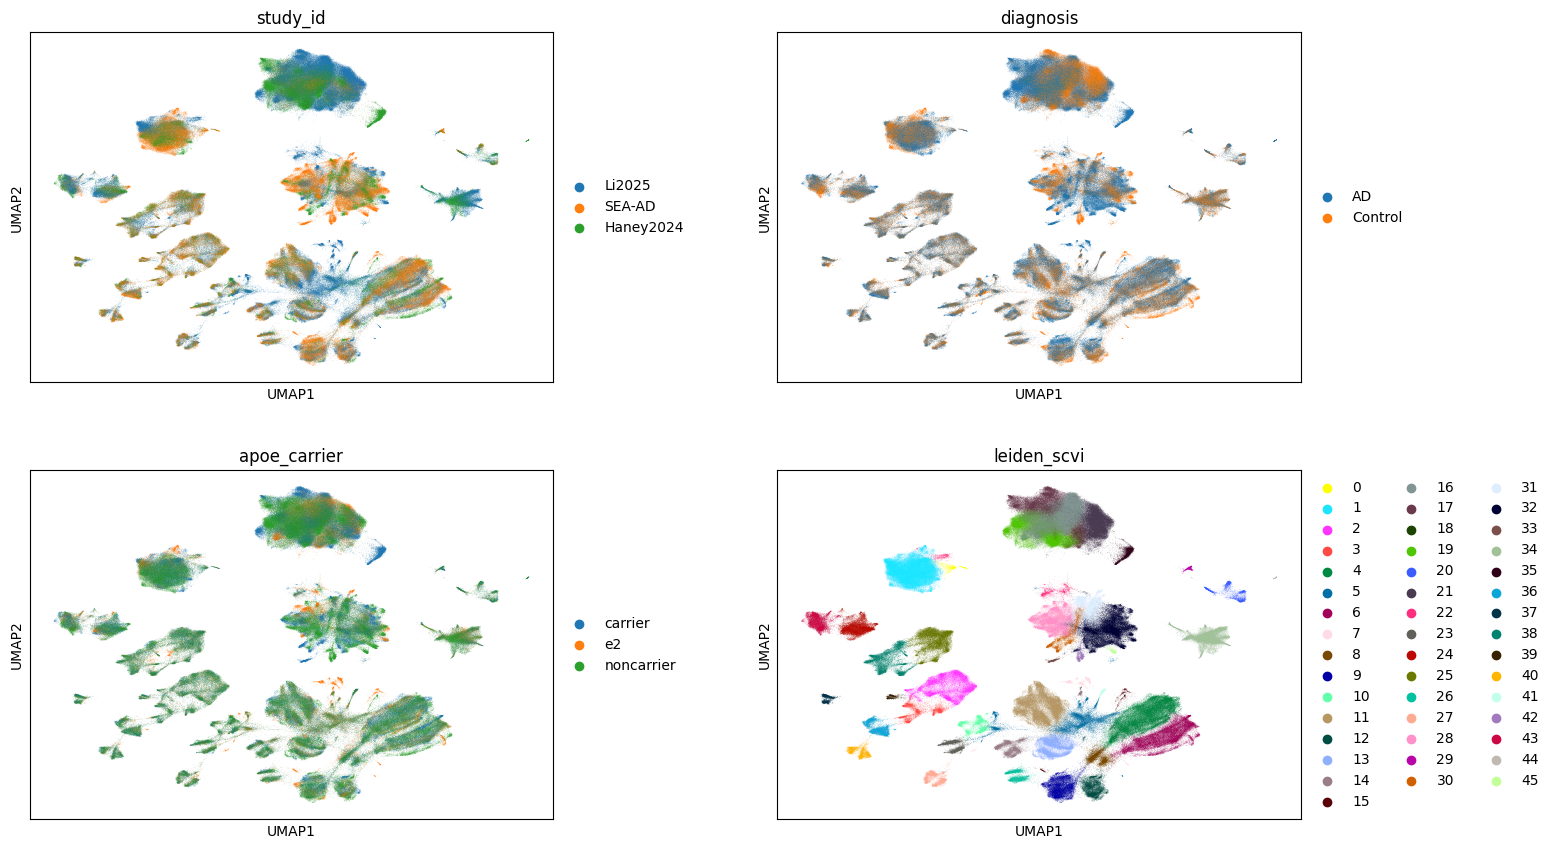

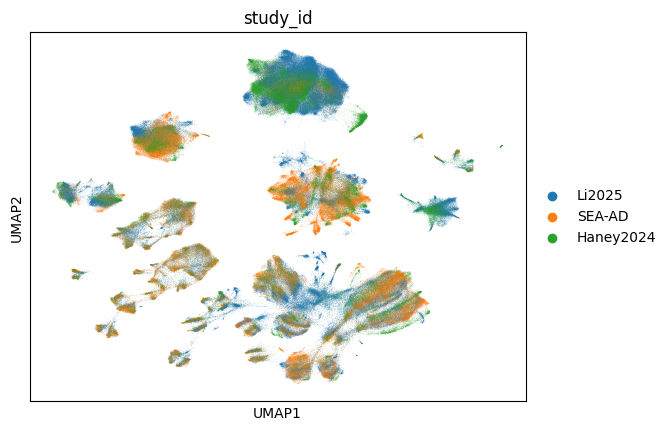

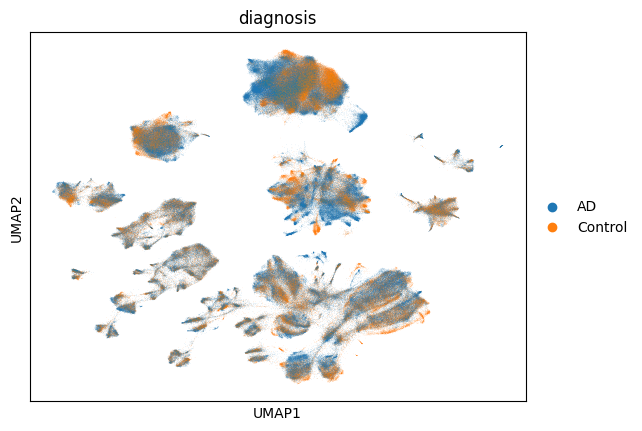

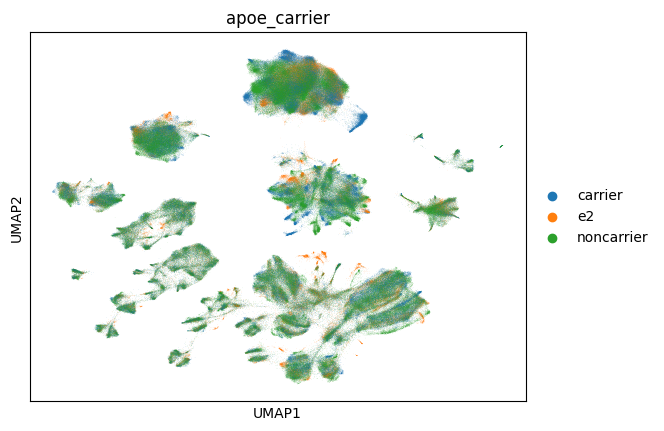

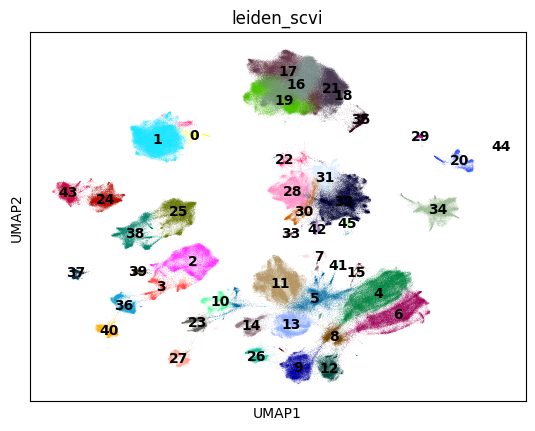

markers shown: ['AQP4', 'GFAP', 'SLC1A2', 'CSF1R', 'AIF1', 'TREM2', 'P2RY12', 'RBFOX3', 'SNAP25', 'MBP', 'MOBP']


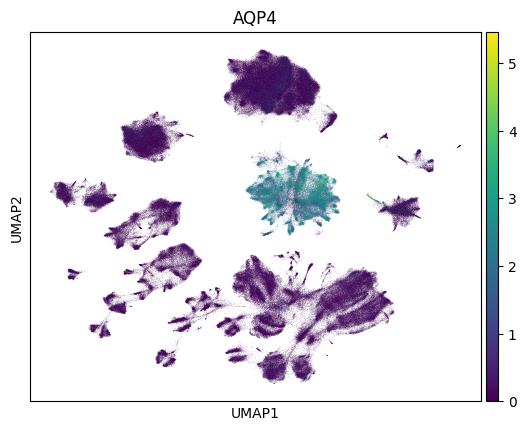

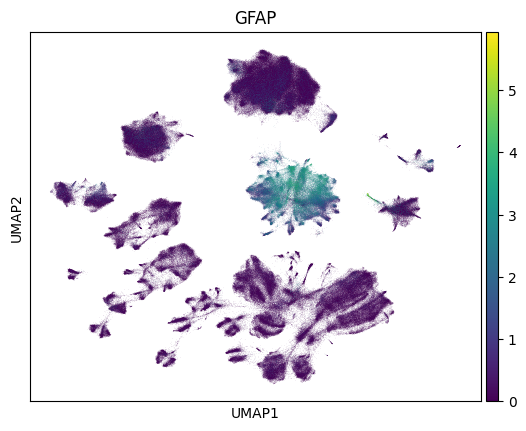

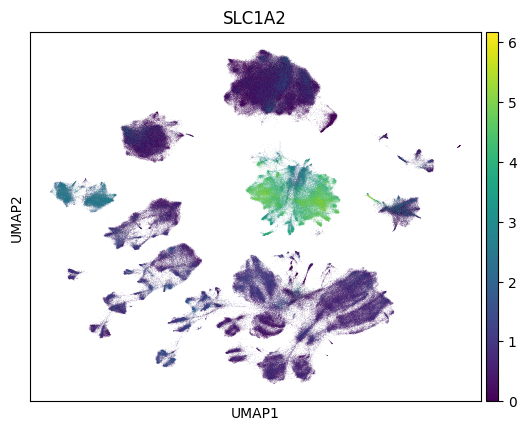

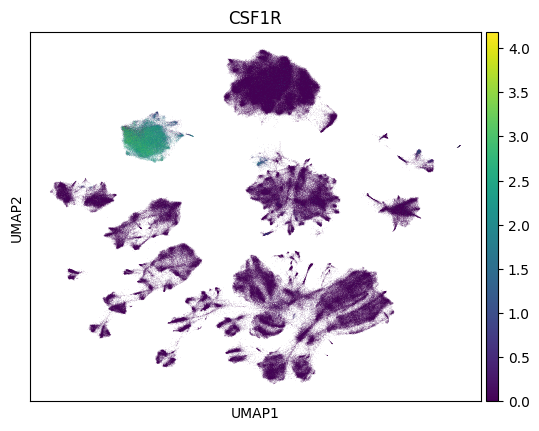

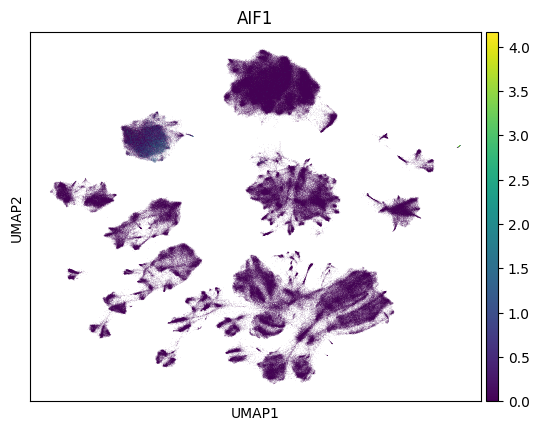

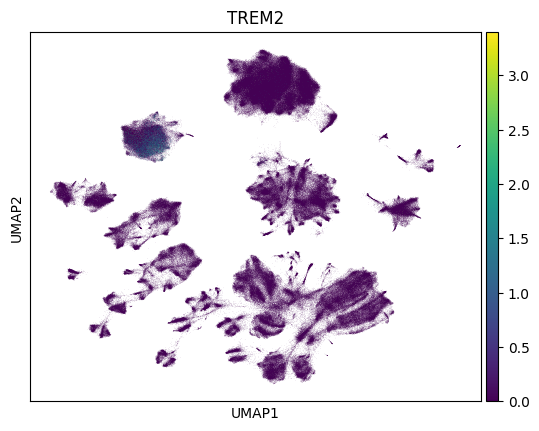

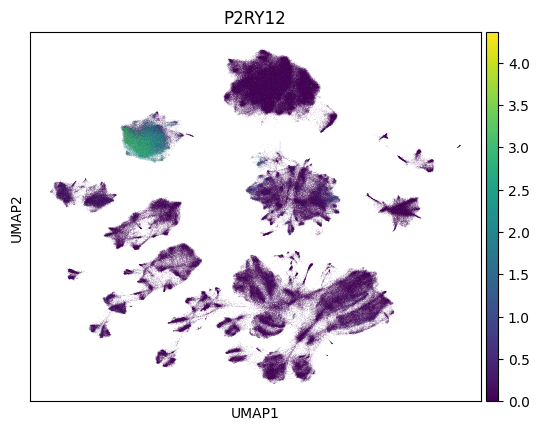

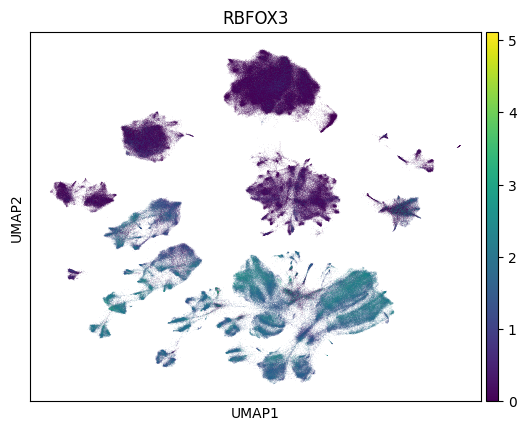

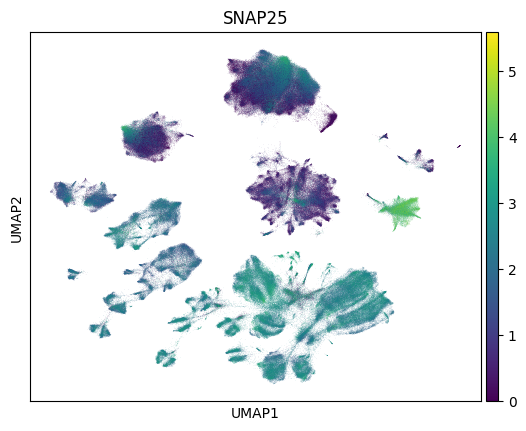

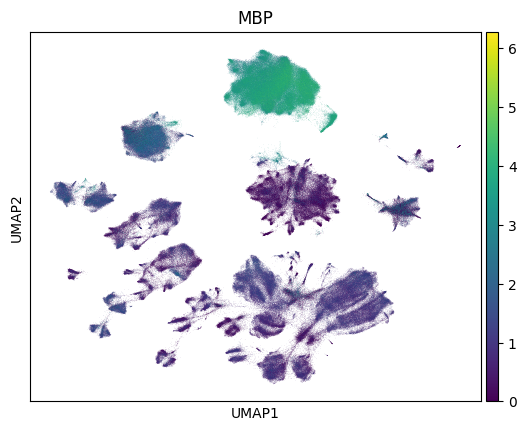

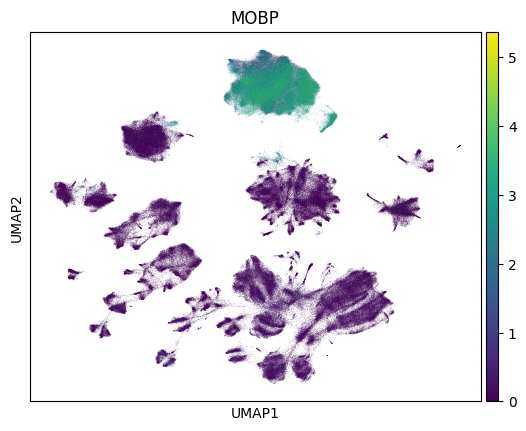

73311

In [9]:
# grid overview
sc.pl.umap(adata, color=["study_id", "diagnosis", "apoe_carrier", "leiden_scvi"],
           ncols=2, wspace=0.3, show=True)

# per-panel full-size for the categoricals (mixing is hard to judge in a small grid)
for c in ["study_id", "diagnosis", "apoe_carrier", "leiden_scvi"]:
    sc.pl.umap(adata, color=c, show=True, title=c,
               legend_loc="on data" if c == "leiden_scvi" else "right margin")

# canonical markers (only those present in the intersection)
markers = [g for g in ["AQP4", "GFAP", "SLC1A2",                 # astrocyte
                       "CSF1R", "AIF1", "TREM2", "P2RY12",       # microglia
                       "RBFOX3", "SNAP25", "MBP", "MOBP"]         # neuron / oligo context
           if g in adata.var_names]
print("markers shown:", markers)

adata.layers["lognorm_vis"] = adata.X.copy()
sc.pp.normalize_total(adata, target_sum=1e4, layer="lognorm_vis")
sc.pp.log1p(adata, layer="lognorm_vis")
for g in markers:
    sc.pl.umap(adata, color=g, layer="lognorm_vis", cmap="viridis", show=True, title=g)
del adata.layers["lognorm_vis"]
adata.uns.pop("log1p", None)   # sc.pp.log1p writes this key; remove so colab_05 isn't
gc.collect()                     # silently skipped if it calls log1p on raw .X

> **Interpretation — integration diagnostics & territory map (6a).**
>
> **This is the central read of the notebook.** Five overlays on one shared UMAP plus 11 marker panels. Caveat first: UMAP geometry is a 2-D distortion of the 30-D latent, so distances and densities are qualitative only — the per-cluster composition table in 6b is the quantitative companion, and any batch claim must be backed there, not from these pictures.
>
> **Territory map (markers -> identity, 46-cluster IDs).** Astrocyte markers AQP4, SLC1A2, GFAP co-light one central mass = clusters **{22, 28, 30, 31, 33, 42, 45}**. Microglia markers CSF1R, P2RY12, AIF1, TREM2 co-light the upper-left island = cluster **1** (plus tiny adjacent **0**). Oligodendrocyte markers MBP, MOBP light the large top-centre mass = **{16, 17, 18, 19, 21}** plus the green right edge **35**. Pan-neuronal RBFOX3, SNAP25 light the whole bottom field and the far-right island **34**. The two niche compartments — astrocytes and microglia — are therefore cleanly identifiable and spatially separate from the oligo/neuron bulk that integrate-then-subset (ITS) will discard.
>
> **study_id — integration quality.** The bulk integrates well: the large central and bottom masses interleave Li / SEA-AD / Haney rather than segregating by colour. It is also not over-corrected — clusters span a wide composition range (6b) instead of collapsing to the global 55/29/16 mean, so biological structure survives while study is largely removed. The exceptions are a few study-pure peripheral islands, adjudicated quantitatively in 6b.
>
> **Microglia (niche half 1) — clean.** Cluster 1 carries all three studies (6b: 0.37 / 0.50 / 0.13) and TREM2 marks a high sub-pocket *inside* it — a DAM-like activated-microglia substate resolving within a single integrated compartment. The one injected gene (4a) earns its place here. This half of the FT substrate is sound.
>
> **Astrocytes (niche half 2) — the open risk.** The astrocyte mass holds well-mixed sub-clusters (28 / 30 / 31, all three studies) **but also** study-segregated ones: cluster 22 is Li-pure and 33 / 42 / 45 are SEA-AD-pure (6b). GFAP shows a genuine reactive-to-homeostatic gradient across the mass, so a substate axis really exists — but study and substate are **confounded** here, and a UMAP cannot separate "study-specific real astrocyte state" from "residual batch scVI failed to merge." Since astrocytes are half the substrate, this is logged as an **open risk, not a solved item**; adjudication (joint GFAP x study x disease on the astrocyte subset, with the hierarchical second-scVI fallback if it proves to be batch) is the first task of colab_05.
>
> **diagnosis & APOE — both correctly *non*-structural.** AD and Control interleave within every cluster (no disease-pure cluster); APOE carrier and non-carrier interleave, with e2 sparse as expected. This is the desired result: neither variable acts as a coarse splitter, so the AD and APOE signals live *within* cell types — where eval#2 must recover them — rather than as gross manifold splits that would imply batch/biology confounding. One caveat not resolvable by eye: the Li-dominant oligodendrocyte mass could carry an APOE x study confound; that needs the quantitative cross-tab in colab_06, which is the reason scANVI (label-aware) is the second integration method.

### 6b — Label-free residual-batch screen (per-cluster study composition)

For each Leiden cluster, the fraction of cells from each study. A cluster drawn almost entirely
from one study is a candidate residual-batch artifact (or a genuine study-private population —
distinguished only after annotation). This is **not** scIB: bio-conservation metrics need
cell-type labels and are deferred to colab_06. This table is the colab_04 integration health
check.

In [10]:
comp = pd.crosstab(adata.obs["leiden_scvi"], adata.obs["study_id"], normalize="index")
print("per-cluster study composition (row-normalized):")
with pd.option_context("display.max_rows", None, "display.width", 120):
    print(comp.round(3))

DOMINANCE = 0.90
dominated = comp.index[comp.max(axis=1) >= DOMINANCE].tolist()
print(f"\nclusters >= {DOMINANCE:.0%} one study (possible residual batch OR study-private): "
      f"{dominated}")
print("\noverall study fractions:",
      adata.obs["study_id"].value_counts(normalize=True).round(3).to_dict())
print("\nNOTE: full scIB (iLISI/kBET batch + NMI/ARI/ASW bio-conservation) is DEFERRED to "
      "colab_06 — bio-conservation needs cell-type labels (annotation = colab_05).")

per-cluster study composition (row-normalized):
study_id     Li2025  SEA-AD  Haney2024
leiden_scvi                           
0             0.204   0.697      0.099
1             0.368   0.503      0.129
2             0.421   0.470      0.110
3             0.308   0.554      0.138
4             0.471   0.417      0.112
5             0.914   0.010      0.076
6             0.420   0.376      0.203
7             0.998   0.001      0.001
8             0.583   0.311      0.106
9             0.442   0.507      0.050
10            0.597   0.234      0.169
11            0.571   0.334      0.095
12            0.561   0.361      0.078
13            0.628   0.258      0.114
14            0.671   0.274      0.055
15            0.007   0.667      0.325
16            0.761   0.076      0.163
17            0.769   0.039      0.192
18            0.705   0.049      0.246
19            0.515   0.047      0.438
20            0.532   0.198      0.270
21            0.857   0.063      0.080
22            0.

> **Interpretation — residual-batch screen (6b).**
>
> Per-cluster study composition, row-normalised, read against the global baseline **Li 0.550 / SEA-AD 0.294 / Haney 0.157**. Fail-loud flags **8 clusters >=90% one study: 5, 7, 22, 33, 35, 42, 44, 45**. Cross-referencing the 6a territory map classifies every one:
>
> - **Non-niche, dropped under ITS, benign (4):** **5, 7** (Li-pure, neuronal/non-glial), **35** (Haney-pure, the oligodendrocyte edge), **44** (Haney-pure, non-glial island). These are discarded with the rest of the non-niche bulk regardless of purity, so their segregation never touches the substrate.
> - **Astrocytes — within-niche residual-batch flag (4):** **22** (Li 0.963) and **33 / 42 / 45** (SEA-AD ca. 0.99 each). These are the only flagged clusters inside the niche and are the open risk surfaced in 6a.
>
> Counter-evidence that this is *not* a global scVI failure: study-pure islands come from **all three** studies, and the major cell types do **not** shatter into three study-versions — microglia is a single mixed cluster, and the astrocyte and neuron bulk are mixed. That pattern fits either a real study-confounded astrocyte state or astrocyte-specific batch, but rules out systematic under-correction. The moderately skewed-but-mixed clusters — SEA-enriched 28 / 29 / 31 (ca. 0.62-0.70), the small microglia-adjacent cluster 0 (SEA 0.70, the same cluster tagged in 6a), and Haney-enriched 19 / 30 (ca. 0.41-0.44) — should **not** be chased: with all three studies present, a 2-3x enrichment is explained by genuine cross-region abundance differences (SEA-AD MTG+DLPFC vs Li temporal vs Haney SFG+fusiform), and "correcting" them would be over-integration. Two zero-presence oddities for annotation: 15 (Li-absent) and 34 (SEA-absent), both neuronal, hence non-niche. Full scIB (iLISI/kBET batch + NMI/ARI/ASW bio-conservation) is correctly deferred to colab_06, which needs the colab_05 labels.

## 7 — Save integrated object + scVI model

### 7a — Save integrated AnnData (full-gene counts + `X_scVI`) to Drive

Write the full-gene object with raw counts in `.X` (CSR), the scVI latent in `obsm["X_scVI"]`,
UMAP, Leiden labels, and the harmonized obs. This is the single hand-off object for colab_05
(annotation + subset) and colab_06 (2nd method + scIB). Drive-only (gitignored).

In [11]:
INTEGRATED_DIR = os.path.join(DRIVE_ROOT, "integrated")
os.makedirs(INTEGRATED_DIR, exist_ok=True)

if not sp.issparse(adata.X) or adata.X.getformat() != "csr":
    adata.X = sp.csr_matrix(adata.X)

INTEGRATED_PATH = os.path.join(INTEGRATED_DIR, "scvi_integrated_full.h5ad")
adata.write_h5ad(INTEGRATED_PATH, compression="gzip")
print(f"Wrote {INTEGRATED_PATH}  ({os.path.getsize(INTEGRATED_PATH)/1e9:.2f} GB)  shape={adata.shape}")
print("  .obsm:", list(adata.obsm.keys()))
print("  .obs :", list(adata.obs.columns))

Wrote /content/drive/MyDrive/ad-glia-fm-prep/integrated/scvi_integrated_full.h5ad  (5.44 GB)  shape=(694922, 26514)
  .obsm: ['X_scVI', 'X_umap']
  .obs : ['donor_id', 'sample_id', 'region', 'apoe_genotype', 'apoe_carrier', 'diagnosis', 'sex', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'orig_celltype', 'study_id', 'leiden_scvi']


> **Interpretation — save integrated object (7a).**
>
> Persists the **post-5c clean** object to Drive: **694,922 x 26,514**, 5.44 GB, retaining **full-gene counts** (not just the 3,001 HVGs) so colab_05 can score any marker, and carrying both `X_scVI` (the 30-D substrate) and `X_umap`, plus every obs column annotation needs downstream (`leiden_scvi`, `diagnosis`, `apoe_carrier`, `study_id`, region, donor). This overwrites the earlier dirty save (pre-5c labels) from the crashed session. The full-gene + latent pairing is exactly what the niche subset and the FM embedding step require; FM work re-loads from this file in the Py-3.10 env.

### 7b — Save trained scVI model

Save the model directory so colab_06 can initialize **scANVI** from this scVI model
(`scANVI.from_scvi_model`) instead of retraining from scratch. `save_anndata=False` — the data is
already on Drive via 7a.

In [12]:
MODEL_DIR = os.path.join(DRIVE_ROOT, "models", "scvi_colab04")
os.makedirs(os.path.dirname(MODEL_DIR), exist_ok=True)
model.save(MODEL_DIR, overwrite=True, save_anndata=False)
print("scVI model saved to", MODEL_DIR)
print("  (colab_06 scANVI can init from this via scvi.model.SCANVI.from_scvi_model)")

scVI model saved to /content/drive/MyDrive/ad-glia-fm-prep/models/scvi_colab04
  (colab_06 scANVI can init from this via scvi.model.SCANVI.from_scvi_model)


> **Interpretation — save scVI model (7b).**
>
> The trained model is saved separately and is **disease-label-agnostic** (conditioned on study_id only), which is why it never needed re-saving across the 5c fix or the prior crash. Its explicit purpose is the colab_06 second method: scANVI initialises from it via `from_scvi_model`, giving a fair label-aware comparison that begins from the identical learned latent instead of retraining from scratch.

## 8 — Handoff to annotation

### 8a — Write integration trace to audit report + summary + commit instructions

Append an `integration_scvi` entry to the cumulative `outputs/audit_report.json` (cells, gene
intersection, HVG count, clusters, study-dominated clusters), then print the artifact list and the
WSL commit commands. Committable: env freeze/JSON + `audit_report.json`. Drive-only: the integrated
h5ad and the scVI model.

In [13]:
import shlex

AUDIT_REPORT_PATH = os.path.join(REPO_PATH, "outputs", "audit_report.json")
with open(AUDIT_REPORT_PATH) as f:
    report = json.load(f)

report["integration_scvi"] = {
    "status": "computed",
    "date": TODAY,
    "n_cells": int(adata.n_obs),
    "n_genes_intersection": int(adata.n_vars),
    "n_hvg": int((adata.var["highly_variable"]).sum()),
    "n_scvi_genes": int(adata.var["in_scvi"].sum()),
    "batch_key": "study_id",
    "n_latent": 30,
    "gene_likelihood": "nb",
    "n_leiden_clusters": int(adata.obs["leiden_scvi"].nunique()),
    "study_dominated_clusters": (
        pd.crosstab(adata.obs["leiden_scvi"], adata.obs["study_id"], normalize="index")
        .pipe(lambda _c: _c.index[_c.max(axis=1) >= 0.90].tolist())
    ),
    "study_fractions": adata.obs["study_id"].value_counts(normalize=True).round(4).to_dict(),
}
with open(AUDIT_REPORT_PATH, "w") as f:
    json.dump(report, f, indent=2)

print("=== Artifacts ===")
print("  committable: ", FREEZE_PATH)
print("  committable: ", ENV_JSON_PATH)
print("  committable: ", AUDIT_REPORT_PATH)
print("  drive-only : ", INTEGRATED_PATH)
print("  drive-only : ", MODEL_DIR)

rel = [os.path.relpath(p, REPO_PATH) for p in (FREEZE_PATH, ENV_JSON_PATH, AUDIT_REPORT_PATH)]
print("\n=== Commit + push (from WSL — Colab has no git creds) ===")
print("  cd /content/ad-glia-fm-prep && git add " + " ".join(shlex.quote(r) for r in rel))
print("  cd /content/ad-glia-fm-prep && git commit -m "
      "'colab_04: scVI integration run record (env + audit trace)'")
print("  cd /content/ad-glia-fm-prep && git push")

=== Artifacts ===
  committable:  /content/ad-glia-fm-prep/outputs/software_versions/colab_04_2026-06-12_pip_freeze.txt
  committable:  /content/ad-glia-fm-prep/outputs/software_versions/colab_04_2026-06-12_env.json
  committable:  /content/ad-glia-fm-prep/outputs/audit_report.json
  drive-only :  /content/drive/MyDrive/ad-glia-fm-prep/integrated/scvi_integrated_full.h5ad
  drive-only :  /content/drive/MyDrive/ad-glia-fm-prep/models/scvi_colab04

=== Commit + push (from WSL — Colab has no git creds) ===
  cd /content/ad-glia-fm-prep && git add outputs/software_versions/colab_04_2026-06-12_pip_freeze.txt outputs/software_versions/colab_04_2026-06-12_env.json outputs/audit_report.json
  cd /content/ad-glia-fm-prep && git commit -m 'colab_04: scVI integration run record (env + audit trace)'
  cd /content/ad-glia-fm-prep && git push


> **Interpretation — handoff + run record (8a).**
>
> Closes the reproducibility loop: pip-freeze, env JSON, and the appended integration trace in `audit_report.json` are committable; the 5.44 GB h5ad and the model stay Drive-only (storage discipline). The printed git block is the manual WSL commit path, since Colab holds no credentials. colab_04 is complete, and the baton passes to colab_05 with a defined agenda: annotate the 46 clusters, subset astrocytes + microglia, adjudicate the astrocyte residual-batch flag (22 and 33 / 42 / 45), re-run Audit C on the 134-donor cohort, and run the carried-forward Li + Haney niche-mito diagnostic.

### Carried forward to colab_05 / colab_06

**colab_05 (annotation + subset):**
- Annotate the integrated object: Leiden + canonical markers; use `orig_celltype` (SEA-AD only)
  as a cross-check, not ground truth.
- Subset astrocytes + microglia (ITS) from the **full-gene** object → save the glia subset for the
  FM notebooks.
- **Carried-forward niche-mito diagnostic (still open from colab_01/03):** among annotated
  astrocytes, check `pct_counts_mt` against the 5% ceiling for pile-up — the genuinely clean
  per-cell-type check that Li (no labels) and Haney (no labels) could not run at QC time.

**colab_06 (2nd method + scIB):**
- Second integration method — **decision pending**: **scANVI** (label-aware, inits from the saved
  scVI model, needs colab_05 labels; the locked plan favors it for the APOE×study confound) vs
  **Harmony** (label-free, runs independently). Run full **scIB** (batch: iLISI/kBET/graph
  connectivity; bio: NMI/ARI/ASW vs cell type) comparing scVI vs the 2nd method, and articulate
  tradeoffs.
- **Audit B flip:** SEA-AD and Li entries are still `skipped` in `audit_report.json` — flip to
  `pass` in the colab_06 audit cell once confirmed.